# Project 2
## Topic: Exploratory Data Analysis of an E-Commerce Sales Dataset
This project focuses on analyzing an e-commerce sales dataset to uncover business insights, customer behaviour patterns, revenue trends, and sales performance.

In [31]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Loading the Dataset
df = pd.read_excel(r"C:\Users\MRS CHIOMA GRAT\Documents\Data Analytics Intern at decodelabs\Cleaned data\Cleaned_dataset_for Data Analytics.xlsx")

### Dataset Overview
This section explores the structure of the dataset, including the number of rows, columns, datatypes, and summary statistics

In [34]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 main st,Debit card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 main st,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 main st,Credit card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 main st,Debit card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 main st,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 main st,Credit card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 main st,Online,Cancelled,TRK69207593,5,NO COUPON,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 main st,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 main st,Debit card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [36]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


### Revenue Analysis
This section analyzes overall revenue performance, revenue distribution, and high-value transactions.

In [37]:
# Analyzing Total Revenue generated, Average Revenue and the single order with the highest revenue
df1 = df["TotalPrice"].sum()
df2 = df["TotalPrice"].mean()
df3 = df["TotalPrice"].max()
print (f"Total Revenue: ${df1:,.2f}")
print (f"Average Revenue: ${df2:,.2f}")
print (f"Highest Single Order: ${df3:,.2f}")

Total Revenue: $1,264,761.96
Average Revenue: $1,053.97
Highest Single Order: $3,456.40


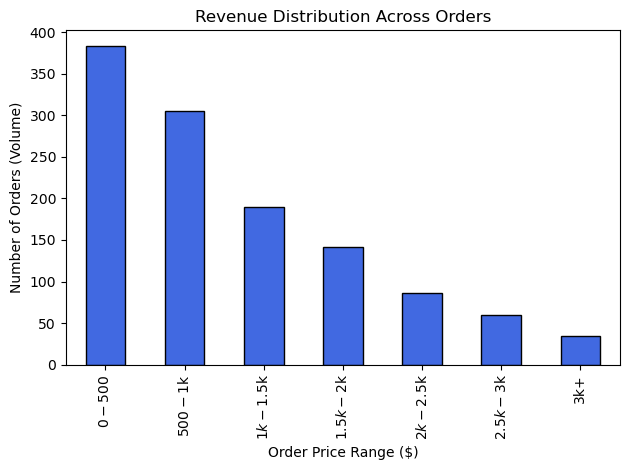

In [40]:
# Analyzing Totalprice(revenue) distribution across orders
bins = [-float("inf"), 500, 1000, 1500, 2000, 2500, 3000, float("inf")]
labels = ["$0-$500", "$500-$1k", "$1k-$1.5k", "$1.5k-$2k", "$2k-$2.5k", "$2.5k-$3k", "3k+"]
df["PriceRange"] = pd.cut(df["TotalPrice"], bins=bins, labels=labels)
range_counts= df["PriceRange"].value_counts().sort_index()
range_counts.plot(kind ="bar", color = "royalblue", edgecolor = "black") 
plt.title("Revenue Distribution Across Orders")
plt.xlabel("Order Price Range ($)")
plt.ylabel("Number of Orders (Volume)")
plt.tight_layout()
plt.savefig("Revenue Distribution.png", dpi = 300)
plt.show()
    

### Insight
Most customer purchases were concentrated within lower price ranges, while higher-value transactions were relatively rare, indicating a right-skewed revenue distribution

### Product Analysis
This section examines product sales performance to identify the most purchased and highest revenue-generating products

In [41]:
# Analyzing Product with the most sale
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

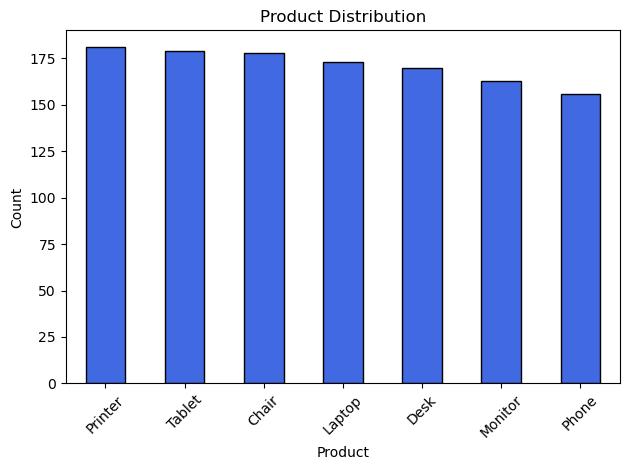

In [42]:
# Visualizing sales by product 
df["Product"].value_counts().plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Product Distribution.png", dpi = 300)
plt.show()


In [11]:
# Analyzing Top Performing Products by Revenue
top_products = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending = False)
print("---Top Products by Total Revenue ---")
for product, revenue in top_products.items():
    print(f"{product}: ${revenue:,.2f}")


---Top Products by Total Revenue ---
Chair: $195,620.11
Printer: $195,612.61
Laptop: $192,126.56
Tablet: $186,568.95
Monitor: $175,651.41
Desk: $167,459.93
Phone: $151,722.39


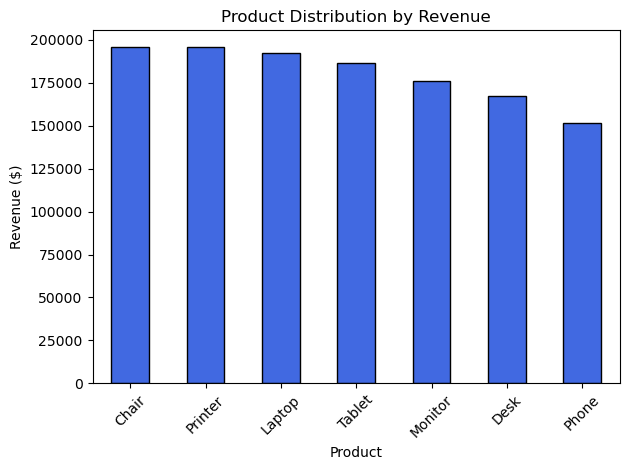

In [12]:
# Visualization: Product Distribution by Revenue
top_products.plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Product Distribution by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Product_distribution_by_Revenue.png", dpi = 300)
plt.show()

### Insight
Printers recorded the highest number of sales transactions, while chairs generated the highest overall revenue.
This suggests that chairs may have had a higher average selling price or higher-value transactions.

### Trend Analysis
This section eveluates the changes in customer purchasing activity across different months

In [43]:
# Extracting Month from Date Column for Time series analysis
df["Month"] = df["Date"].dt.month_name()
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,PriceRange,Month
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 main st,Debit card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,$2.5k-$3k,January
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 main st,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,$0-$500,August
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 main st,Credit card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,$2.5k-$3k,February
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 main st,Debit card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,$0-$500,October
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 main st,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,$2.5k-$3k,May
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 main st,Credit card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,$0-$500,June
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 main st,Online,Cancelled,TRK69207593,5,NO COUPON,Facebook,1325.06,$1k-$1.5k,March
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 main st,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,$500-$1k,July
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 main st,Debit card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,$1k-$1.5k,August


In [44]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["Month"] = pd.Categorical(df["Month"],categories = month_order, ordered = True)

In [45]:
# Monthly Sales Trend
monthly_sales = df["Month"].value_counts().sort_index()
monthly_sales

Month
January      106
February     106
March        128
April        113
May          120
June         147
July          87
August        79
September     73
October       78
November      76
December      87
Name: count, dtype: int64

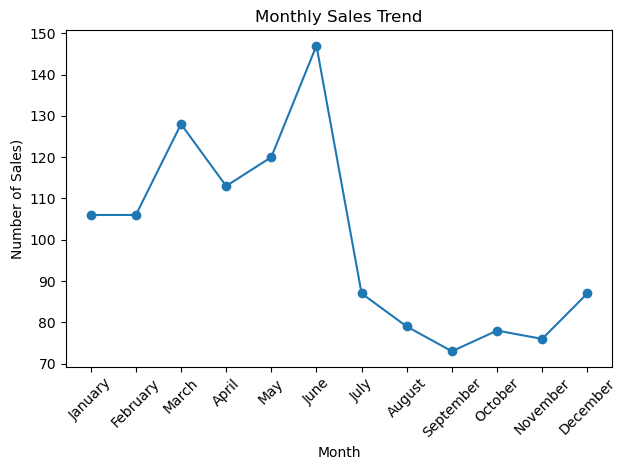

In [46]:
# Visualization: Monthly Sales Trend
df["Month"].value_counts().sort_index().plot(kind = "line", marker = "o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Number of Sales)")
plt.xticks(ticks = range(len(monthly_sales.index)), labels = monthly_sales.index,rotation = 45)
plt.tight_layout()
plt.savefig("Monthly_sales_trend.png", dpi = 300)
plt.show()

In [29]:
# Monthly Revenue Trend
monthly_sales = df.groupby("Month", observed = False)["TotalPrice"].sum()
print("---Revenue Breakdown by Months ---")
for month, revenue in monthly_sales.items():
    print(f"{month}: ${revenue:,.2f}")


---Revenue Breakdown by Months ---
January: $124,313.23
February: $112,344.78
March: $123,840.93
April: $109,186.05
May: $135,142.59
June: $170,616.13
July: $85,784.64
August: $86,343.21
September: $69,321.65
October: $89,834.82
November: $75,493.43
December: $82,540.50


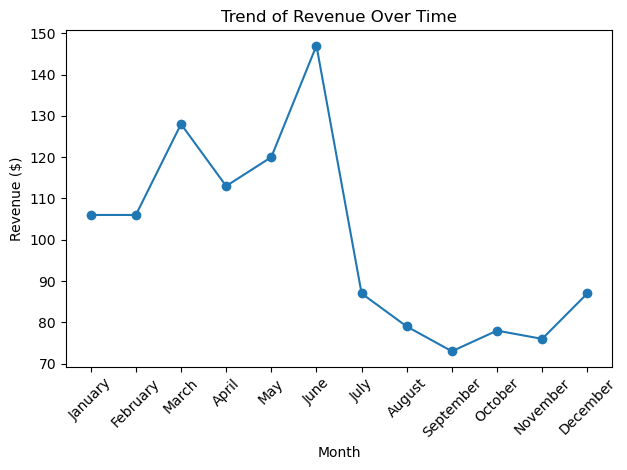

In [47]:
monthly_sales.plot(kind = "line", marker = "o")
plt.title("Trend of Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(ticks = range(len(monthly_sales.index)), labels = monthly_sales.index,rotation =45)
plt.tight_layout()
plt.savefig("Revenue_trend_overtime.png", dpi = 300)
plt.show()

### Insight
Revenue and sales activity both peaked in June, suggesting a period of stronger customer demand and purchasing activity during the mid-year period.

### Order Status Analysis
This section analyzes the distribution of order statuses to evaluate order fulfillment performance and identify potential operational issues.

In [48]:
# Order Status Breakdown by Count
Order_status_by_count = df["OrderStatus"].value_counts()
print ("--- Order Status Breakdown by Count ---")
for status, count in Order_status_by_count.items():
    print(f"{status}: {count}")

--- Order Status Breakdown by Count ---
Cancelled: 250
Returned: 247
Pending: 237
Shipped: 235
Delivered: 231


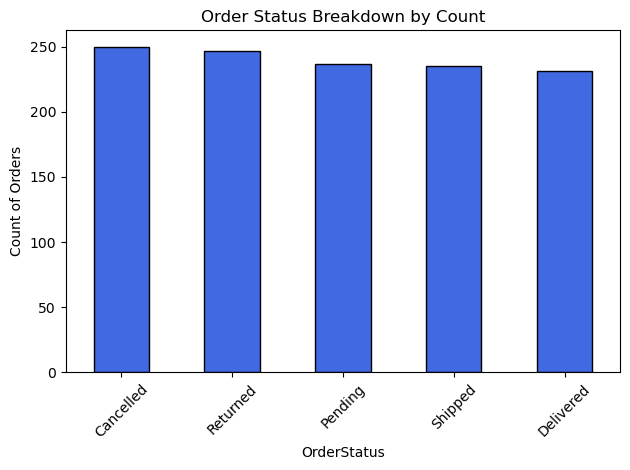

In [49]:
Order_status_by_count.plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Order Status Breakdown by Count")
plt.xlabel("OrderStatus")
plt.ylabel("Count of Orders")
plt.xticks(rotation = 45)
plt.tight_layout()          
plt.savefig("Order_status_breakdown_by_count.png", dpi = 300)
plt.show()

In [22]:
# Analyzing Order Status By Revenue
Order_status_by_revenue = df.groupby("OrderStatus")["TotalPrice"].sum().sort_values(ascending = False)
print("---Revenue Breakdown by Order Status ---")
for status, revenue in Order_status_by_revenue.items():
    print(f"{status}: ${revenue:,.2f}")

---Revenue Breakdown by Order Status ---
Cancelled: $276,396.21
Pending: $256,328.15
Shipped: $246,159.58
Returned: $243,277.70
Delivered: $242,600.32


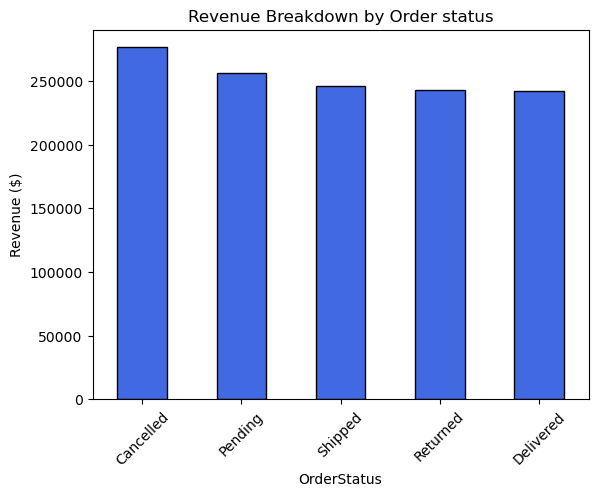

In [23]:
# Visualization
Order_status_by_revenue.plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Revenue Breakdown by Order status")
plt.xlabel("OrderStatus")
plt.ylabel("Revenue ($)")
plt.xticks(rotation = 45)
plt.show()

In [50]:
# Analyzing Order Status Across Different Product Categories
cancel_matrix = pd.crosstab(df["Product"], df["OrderStatus"])
cancel_matrix.columns.name = None
cancel_matrix

,Cancelled,Delivered,Pending,Returned,Shipped
Product,,,,,
Chair,45,33,41,28,31
Desk,35,32,38,32,33
Laptop,35,40,30,39,29
Monitor,35,31,29,36,32
Phone,31,38,28,31,28
Printer,35,29,37,38,42
Tablet,34,28,34,43,40


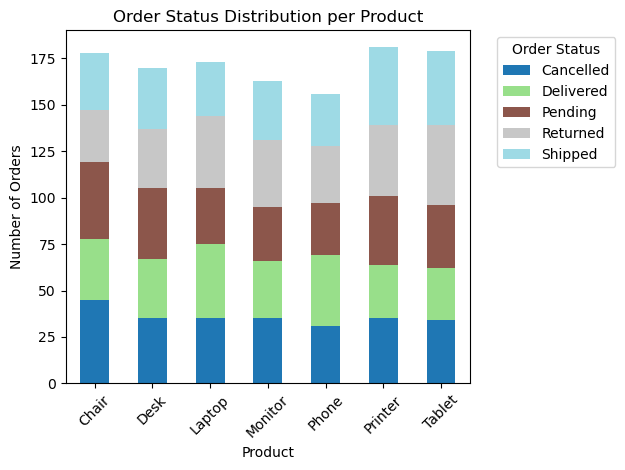

In [52]:
cancel_matrix.plot(kind = "bar", stacked = True, colormap = "tab20")
plt.title("Order Status Distribution per Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45)
plt.legend(title = "Order Status", bbox_to_anchor = (1.05, 1.0), loc = "upper left")
plt.tight_layout()
plt.savefig("Order_status_distribution_per_product.png", dpi = 300)
plt.show()

### Insight
Cancelled orders recorded the highest count, followed closely by returned and pending orders. Delivered orders were slightly lower than cancelled orders, suggesting potential fulfillment or customer satisisfaction challenges the business process.

Additionally, cancelled orders accounted for a significant portion of total revenue, indicating that a significant amount of potential revenue was lost through orders cancellations.

### Payment Method Analysis
This section evaluates customer payment preferences across different transaction methods and how these payment methods relate to order outcomes 

In [53]:
# Analyzing the payment method mostly preferred
payment_method_by_count = df["PaymentMethod"].value_counts()
print ("--- Payment Method Breakdown By Count ---")
for payment, count in payment_method_by_count.items():
    print(f"{payment}: {count}")


--- Payment Method Breakdown By Count ---
Online: 258
Cash: 246
Credit card: 234
Debit card: 232
Gift card: 230


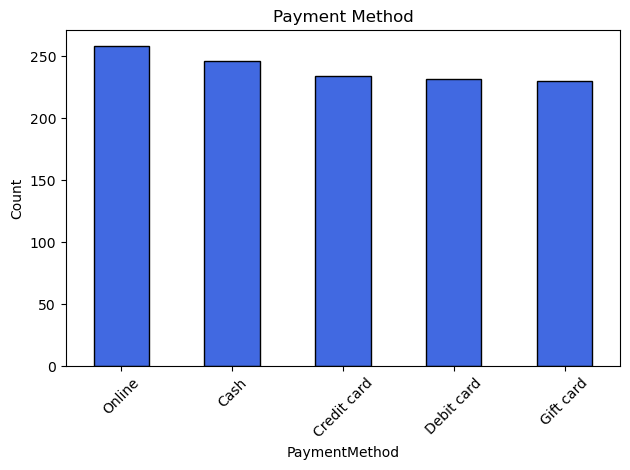

In [55]:
payment_method_by_count.plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Payment Method")
plt.xlabel("PaymentMethod")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Payment_preference_by_count.png", dpi = 300)
plt.show()

In [36]:
# Analyzing Order Status Across Different Payment Method
payment_matrix = pd.crosstab(df["PaymentMethod"], df["OrderStatus"])
payment_matrix.columns.name = None
payment_matrix

,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Cash,49,45,52,57,43
Credit Card,54,43,48,49,40
Debit Card,44,43,55,51,39
Gift Card,50,37,35,52,56
Online,53,63,47,38,57


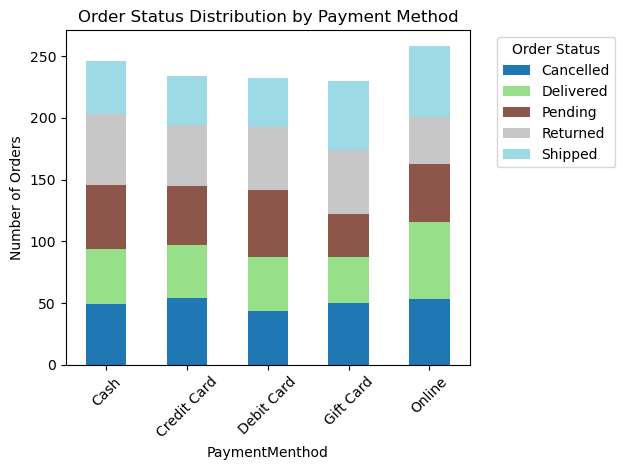

In [37]:
payment_matrix.plot(kind = "bar", stacked = True, colormap = "tab20")
plt.title("Order Status Distribution by Payment Method")
plt.xlabel("PaymentMenthod")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45)
plt.legend(title = "Order Status", bbox_to_anchor = (1.05, 1.0), loc = "upper left")
plt.tight_layout()
plt.savefig("Order_status_distribution_by_paymentmethod.png", dpi = 300)
plt.show()

### Insight
Online payments were the most preferred payment method among customers, while gift cards were the least utilized, suggesting that customers favored faster and more convenient digital payment options over alternative pyment methods. 

Also although online payments recorded the highest number of delivered orders, returned and cancelled orders were relatively distributed across all payment methods thus indictaing that payment method alone was not a major factor influencing unsucessful transactions.

### Referral Source Analysis
This section evaluates customer acquisition channels and their contribution to overall revenue generation.

In [56]:
# Analyzing the platfom that brings the most customers
referral_source_by_count = df["ReferralSource"].value_counts()
print ("--- Referral Source Breakdown by Count ---")
for referral, count in referral_source_by_count.items():
    print(f"{referral}: {count}")

--- Referral Source Breakdown by Count ---
Instagram: 259
Email: 250
Google: 241
Facebook: 228
Referral: 222


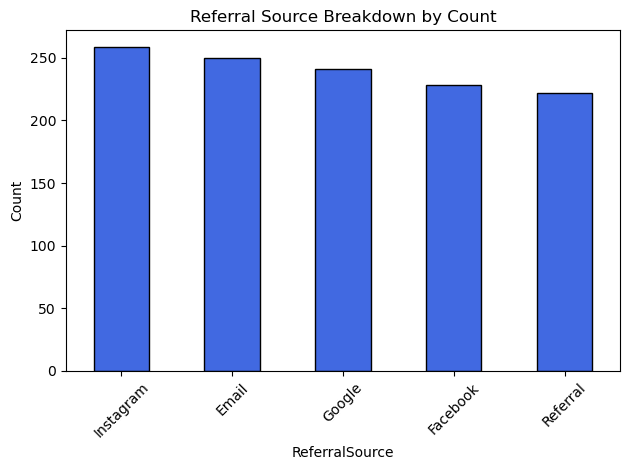

In [57]:
referral_source_by_count.plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Referral Source Breakdown by Count")
plt.xlabel("ReferralSource")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Breakdown_of_ReferralChannel_by_count.png", dpi = 300)
plt.show()

In [29]:
# Analyzing the platform that generates the most revenue
referral_source_by_revenue = df.groupby("ReferralSource")["TotalPrice"].sum().sort_values(ascending = False)
print("---Revenue Breakdown by Referral Source ---")
for referral, revenue in referral_source_by_revenue.items():
    print(f"{referral}: ${revenue:,.2f}")


---Revenue Breakdown by Referral Source ---
Instagram: $275,285.45
Email: $261,808.55
Google: $250,441.48
Facebook: $250,410.90
Referral: $226,815.58


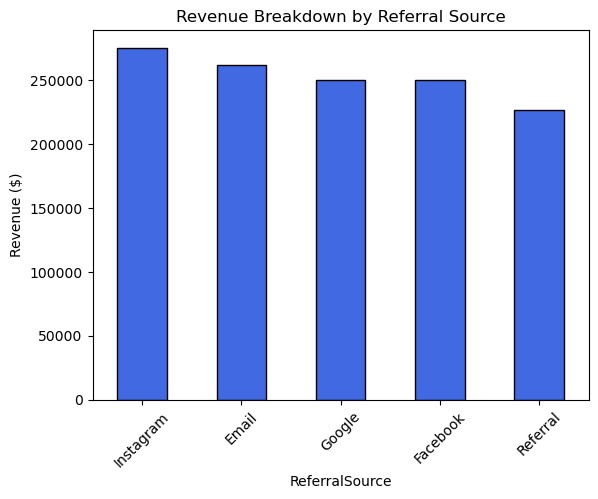

In [30]:
referral_source_by_revenue.plot(kind = "bar", color = "royalblue", edgecolor = "black")
plt.title("Revenue Breakdown by Referral Source")
plt.xlabel("ReferralSource")
plt.ylabel("Revenue ($)")
plt.xticks(rotation = 45)
plt.show()

### Insight
Instagram generated both the highest customer traffic and the highest revenue contribution among all referral sources. This suggests that Instagram marketing efforts were more effective in driving customer engagement and sales compared to other channels.

### Coupon Code Analysis
This section analyzes customer engagement with promotional coupon codes

In [58]:
# Analyzing Customers with Coupon Orders
coupon_orders= (df["CouponCode"] != "NO COUPON").sum()
print(f"Customers with Coupon Orders: {coupon_orders}")

Customers with Coupon Orders: 891


In [59]:
# Analyzing the most frequently ordered coupon
frequently_used_coupons_by_count = df[df["CouponCode"] != "NO COUPON"]["CouponCode"].value_counts()
print("--- Frequently Used Coupons ---")
for couponcode, count in frequently_used_coupons_by_count.items():
   print(f"Coupon Code, {couponcode}: {count}")


--- Frequently Used Coupons ---
Coupon Code, FREESHIP: 313
Coupon Code, WINTER15: 292
Coupon Code, SAVE10: 286


In [60]:
# Percentage of Coupon Usage
coupon_percentage = (coupon_orders/len(df))*100
print (f"Coupon Usage Rate: {coupon_percentage:.2f}%")

Coupon Usage Rate: 74.25%


In [28]:
# Coupon Code Distribution Across Referral Source
coupon_df = df[df["CouponCode"] != "NO COUPON"]
coupon_code_distribution = pd.crosstab(coupon_df["ReferralSource"], coupon_df["CouponCode"])
coupon_code_distribution.columns.name=None
coupon_code_distribution

,FREESHIP,SAVE10,WINTER15
ReferralSource,,,
Email,68,61,66
Facebook,61,46,54
Google,58,66,51
Instagram,73,57,68
Referral,53,56,53


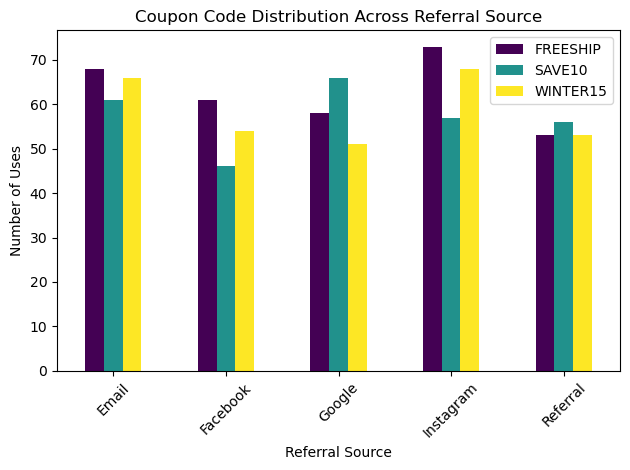

In [61]:
coupon_code_distribution.plot(kind = "bar", colormap = "viridis")
plt.title("Coupon Code Distribution Across Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Uses")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("CouponCode_distribution_across_referral_source.png", dpi = 300)
plt.show()

### Insight
Approximately 74% of customers used coupon codes, indicating strong engagement with promotonal offers. The FREESHIP coupon was the most frequently used while SAVE10 was least used. This suggests that free shipping promotions may have had stronger customer appeal compared to percentage discount offers.

Also Instagram recorded the highest coupon usage among all referral sources, suggesting that customers from this channel were more responsive to promotional offers, whereas Referral traffic showed the lowest coupon engagement, indicating weaker promotional interaction from that channel.

### Customer Behavior Analysis
This section identifies high-value customers based on total revenue contribution

In [62]:
# Top Customers that generate the most revenue
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending = False).head(10)
print("--- Top 10 Customer by Total Revenue ---")
for customer, revenue in top_customers.items():
    print(f"Customer Id, {customer}: ${revenue:,.2f}")

--- Top 10 Customer by Total Revenue ---
Customer Id, C38840: $5,723.23
Customer Id, C57276: $3,456.40
Customer Id, C67260: $3,390.80
Customer Id, C13877: $3,384.90
Customer Id, C18404: $3,370.20
Customer Id, C16775: $3,353.75
Customer Id, C65986: $3,352.40
Customer Id, C47778: $3,334.00
Customer Id, C59183: $3,322.55
Customer Id, C25276: $3,313.90


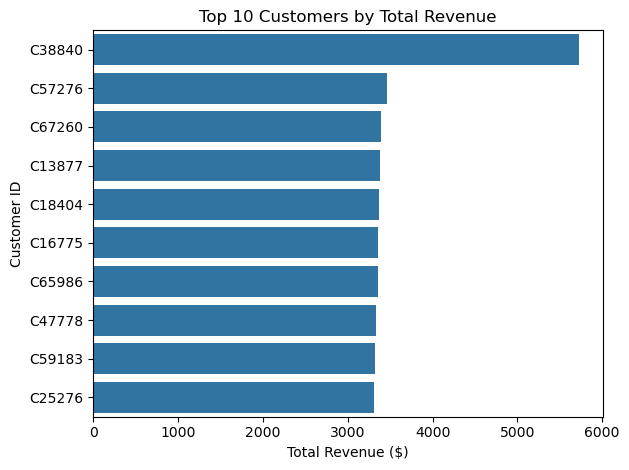

In [63]:
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Customers by Total Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("Top_customers_by_revenue.png", dpi = 300)
plt.show()

### Insight
A small group of customers contributed significantly higher revenue compared to the rest of the customer base.
Customer with ID C38840 generated the highest total revenue ($5,723.23), highlighting the presence of high-value customers who may be important for customer retention strategies.

### Correlation Analysis
This section identifies the relationship between numerical variables such as Quantity, Unit Price, and Total Price (Revenue).

In [64]:
# Analyzing how numerical variables move together
numeric_df = df[["Quantity","UnitPrice", "TotalPrice"]]
correlation = numeric_df.corr()
print("--- Numeric Correlation Matrix ---")
print(correlation)

--- Numeric Correlation Matrix ---
            Quantity  UnitPrice  TotalPrice
Quantity    1.000000   0.014553    0.615251
UnitPrice   0.014553   1.000000    0.717081
TotalPrice  0.615251   0.717081    1.000000


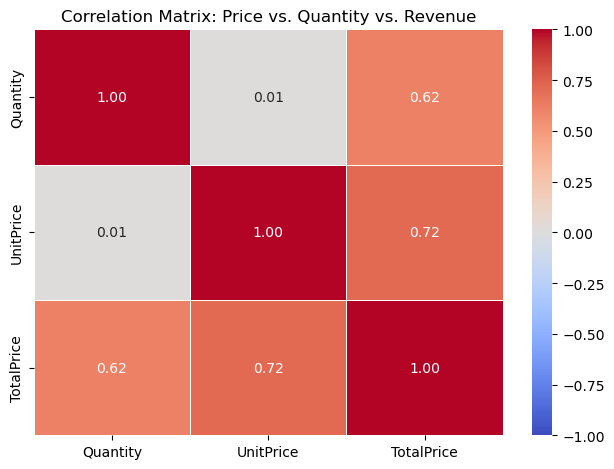

In [65]:
sns.heatmap(correlation, annot = True, cmap = "coolwarm", fmt = ".2f", vmin = -1, vmax = 1, linewidths = 0.5)
plt.title("Correlation Matrix: Price vs. Quantity vs. Revenue")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi = 300)
plt.show()

### Insight
This analysis revealed a strong positive relationship between Unit Price, and Total Revenue, indicating that higher-priced products contributed significantly to overall revenue generation. Quantity also showed a moderate positive relationship with Total Price(revenue), suggesting that larger purchase quantities increased revenue as well.
However, Quantity and Unit-price showed almost no relationship indicating that product pricing did not significantly influence quantity of items purchased.